# Model Explainability (SHAP)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
%matplotlib inline
shap.initjs()

xgboost_model = joblib.load('../../models/xgb_churn_model.pkl')
X_train, X_test, _, _, _, _ = joblib.load('../../models/train_test_data.pkl')
print('Loaded Model and Data')


C:\Users\Gaurav Garg\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded Model and Data


# 6. Model Explainability (SHAP)
Using SHapley Additive exPlanations to interpret feature importances directly from the best tree-based model.

In [2]:
# Ensure SHAP is available
try:
    import shap
except ImportError:
    print('Installing shap library...\n')
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap
    
shap.initjs()

# We typically use SHAP on a tree model
xgb_model = xgboost_model

# Explain the model's predictions using SHAP
# To speed up SHAP, using a background dataset of 5,000 random samples
X_train_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)

print('Calculating SHAP values... (this might take a minute)')
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_sample)

print('SHAP values calculated successfully!')

Calculating SHAP values... (this might take a minute)


SHAP values calculated successfully!


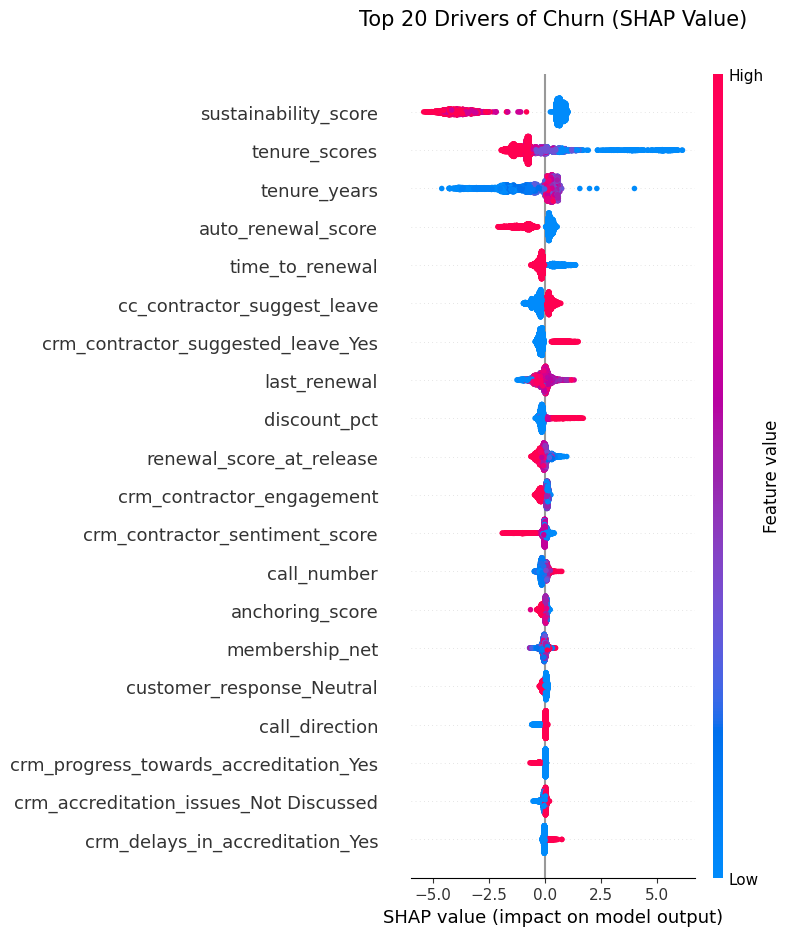

In [3]:
# Plot Global Feature Importance (SHAP Summary Plot)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_train_sample, max_display=20, plot_type='dot', show=False)
plt.title('Top 20 Drivers of Churn (SHAP Value)', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

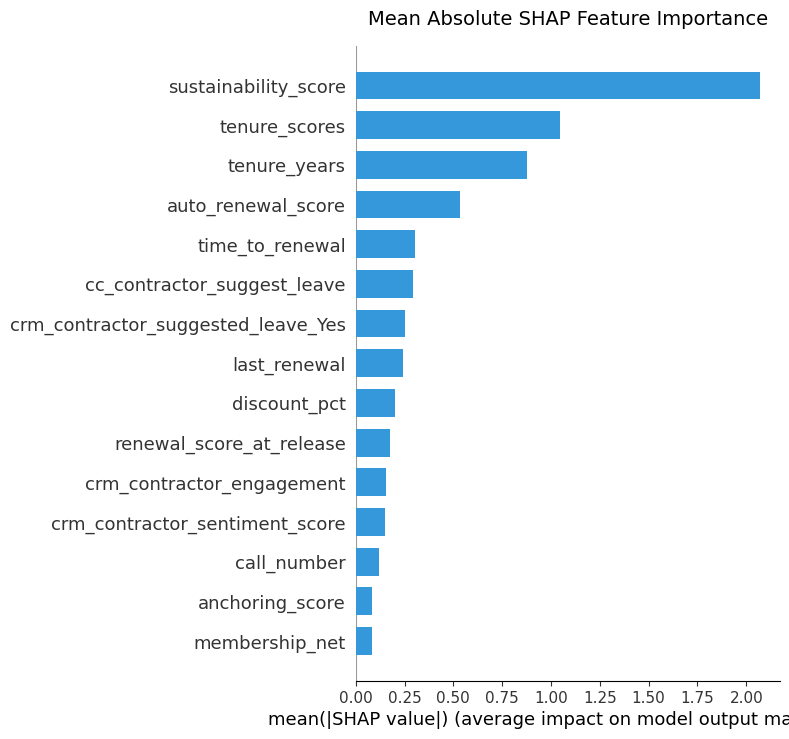

In [4]:
# Plot Feature Importance strictly via Magnitude
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_sample, max_display=15, plot_type='bar', color='#3498db', show=False)
plt.title('Mean Absolute SHAP Feature Importance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Top 2 strongest predictors for partial dependence analysis: ['sustainability_score', 'tenure_scores']


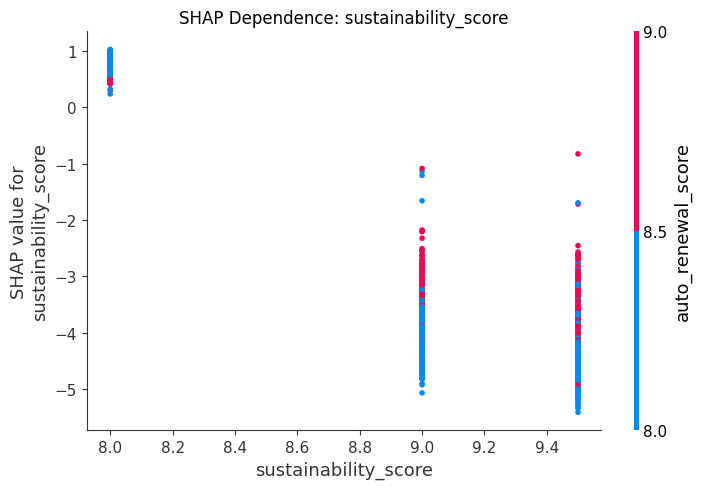

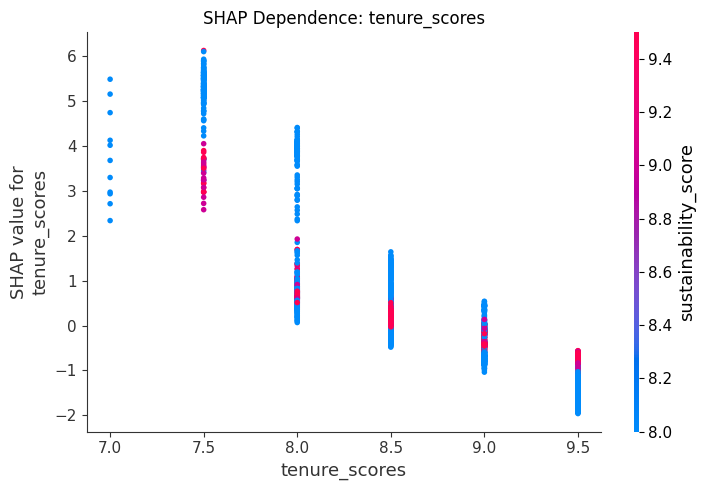

In [5]:
# Top feature Dependence Plot
vals = np.abs(shap_values).mean(0)
feature_names = X_train_sample.columns
feature_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)
top_2_features = feature_importance['col_name'].head(2).tolist()

print(f'Top 2 strongest predictors for partial dependence analysis: {top_2_features}')

if len(top_2_features) >= 1:
    shap.dependence_plot(top_2_features[0], shap_values, X_train_sample, show=False)
    plt.title(f'SHAP Dependence: {top_2_features[0]}', fontsize=12)
    plt.tight_layout()
    plt.show()
    
if len(top_2_features) >= 2:
    shap.dependence_plot(top_2_features[1], shap_values, X_train_sample, show=False)
    plt.title(f'SHAP Dependence: {top_2_features[1]}', fontsize=12)
    plt.tight_layout()
    plt.show()